<a href="https://colab.research.google.com/github/batoolabualhayjaa33-droid/ML-final-project/blob/main/OnlineNewsPopularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [25]:
news_data = pd.read_csv("OnlineNewsPopularity.csv")

display(news_data.head())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [26]:
news_data.columns = news_data.columns.str.strip()

In [27]:
print(news_data.shape)

(39644, 61)


In [28]:
print(news_data.columns)

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [29]:
news_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

In [30]:
display(news_data.describe())

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [31]:
missing_values = news_data.isnull().sum()

print(missing_values)

url                             0
timedelta                       0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
                               ..
title_subjectivity              0
title_sentiment_polarity        0
abs_title_subjectivity          0
abs_title_sentiment_polarity    0
shares                          0
Length: 61, dtype: int64


In [32]:
duplicate_rows = news_data.duplicated().sum()

print(duplicate_rows)

0


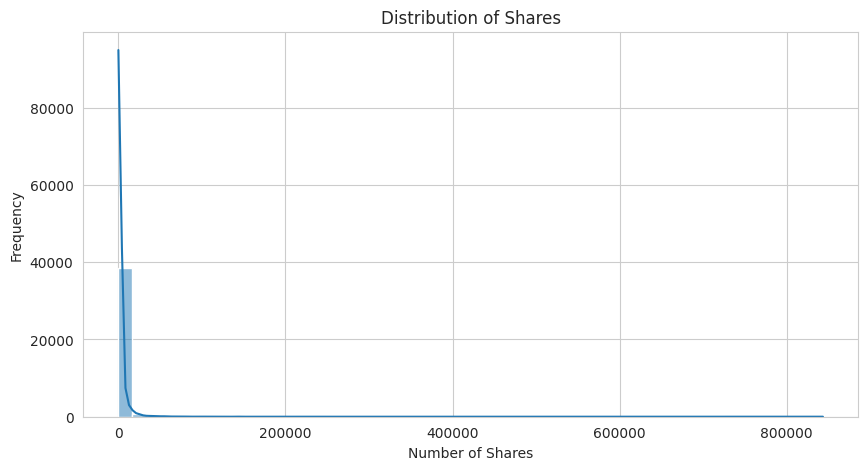

In [33]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(news_data['shares'], bins=50, kde=True)

plt.title("Distribution of Shares")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")

plt.show()

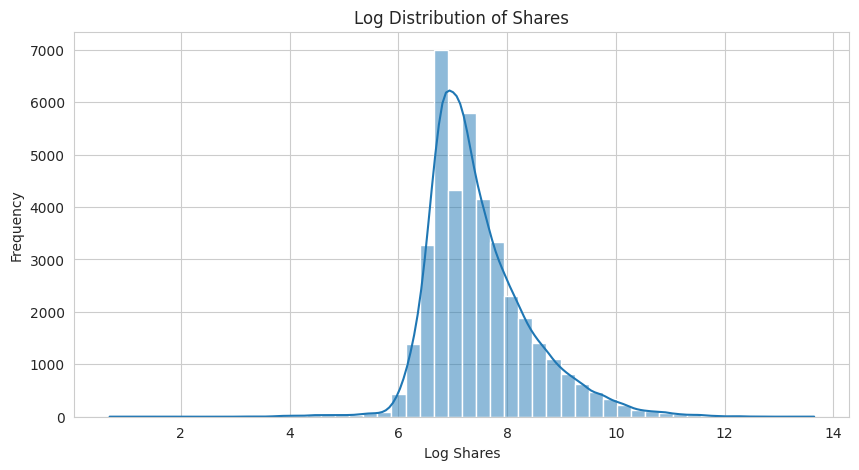

In [34]:
news_data['log_shares'] = np.log1p(news_data['shares'])

plt.figure(figsize=(10,5))

sns.histplot(news_data['log_shares'], bins=50, kde=True)

plt.title("Log Distribution of Shares")
plt.xlabel("Log Shares")
plt.ylabel("Frequency")

plt.show()

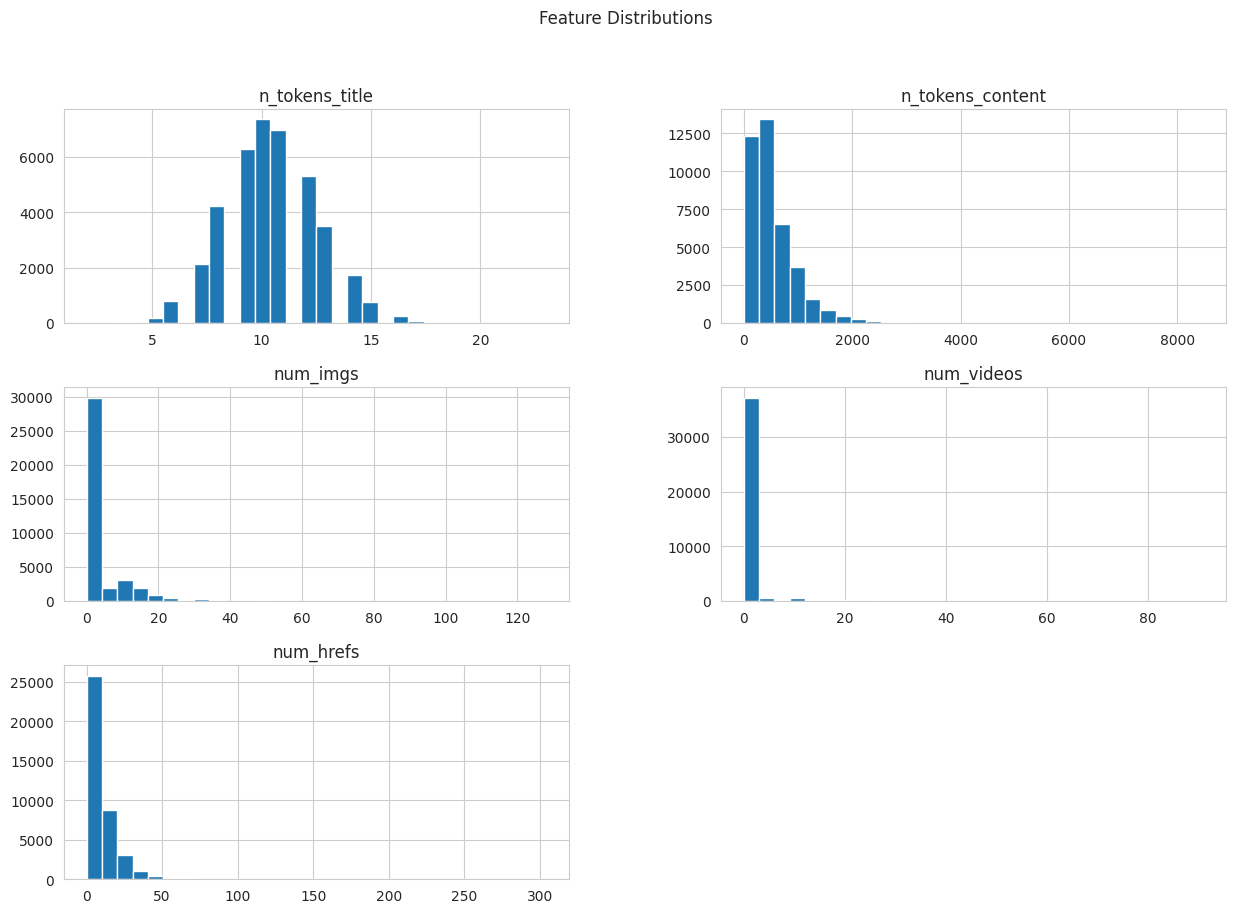

In [35]:
important_features = [
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]

news_data[important_features].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("Feature Distributions")

plt.show()

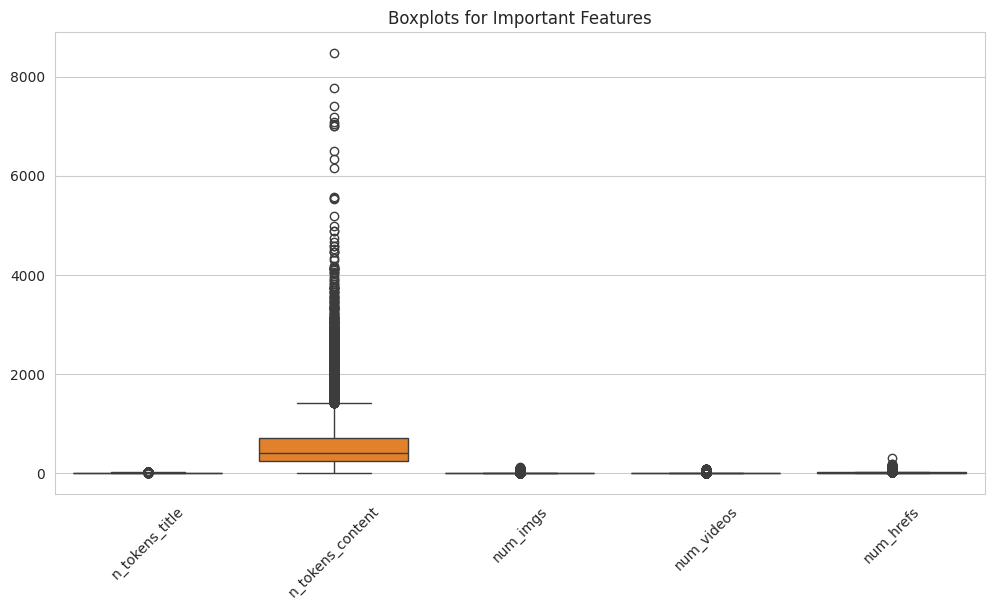

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[important_features])

plt.title("Boxplots for Important Features")

plt.xticks(rotation=45)

plt.show()

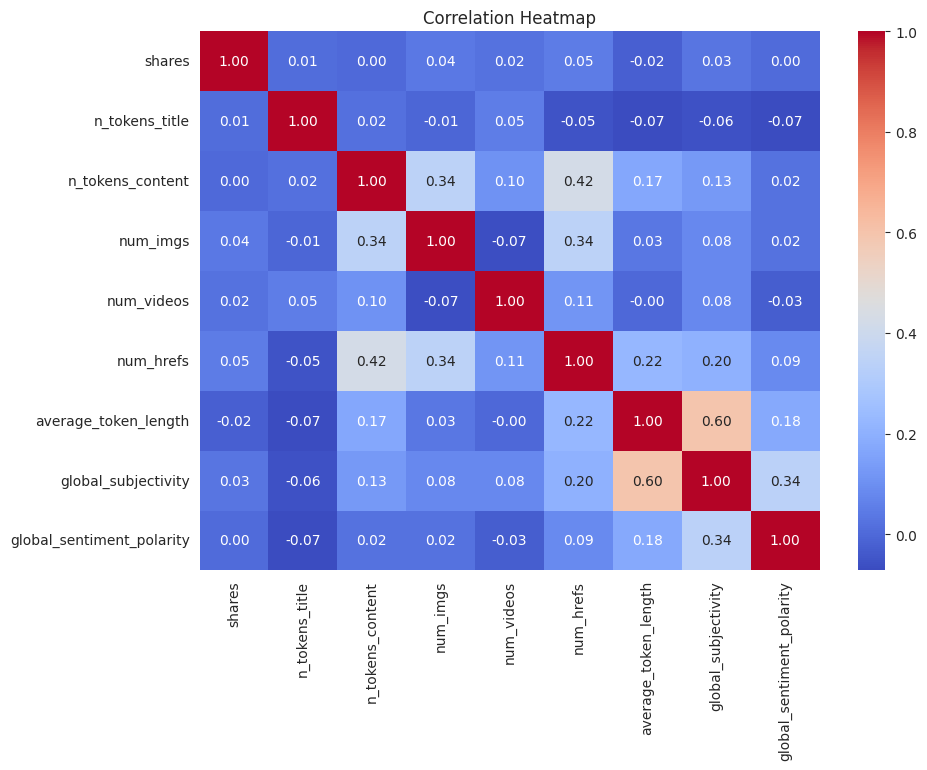

In [37]:
selected_columns = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs',
    'average_token_length',
    'global_subjectivity',
    'global_sentiment_polarity'
]

correlation_matrix = news_data[selected_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

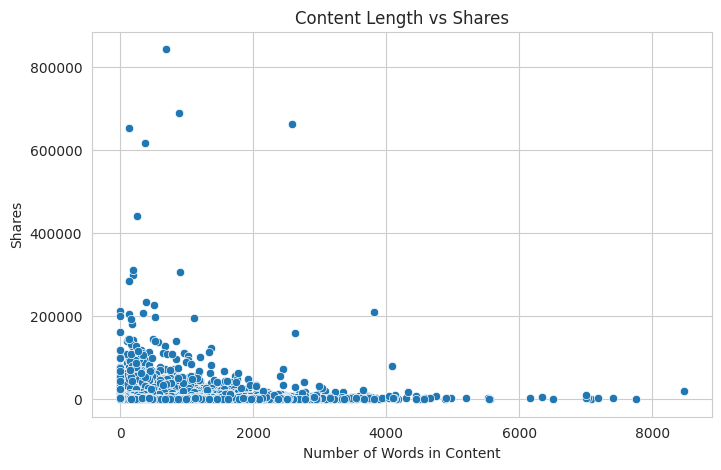

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['n_tokens_content'],
    y=news_data['shares']
)

plt.title("Content Length vs Shares")
plt.xlabel("Number of Words in Content")
plt.ylabel("Shares")

plt.show()

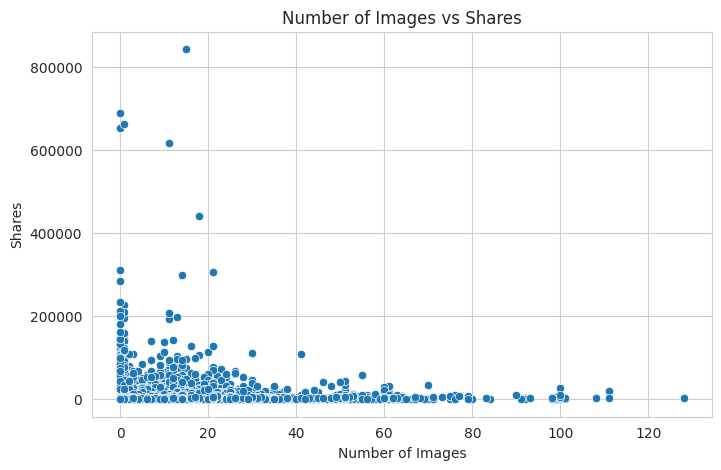

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['num_imgs'],
    y=news_data['shares']
)

plt.title("Number of Images vs Shares")
plt.xlabel("Number of Images")
plt.ylabel("Shares")

plt.show()

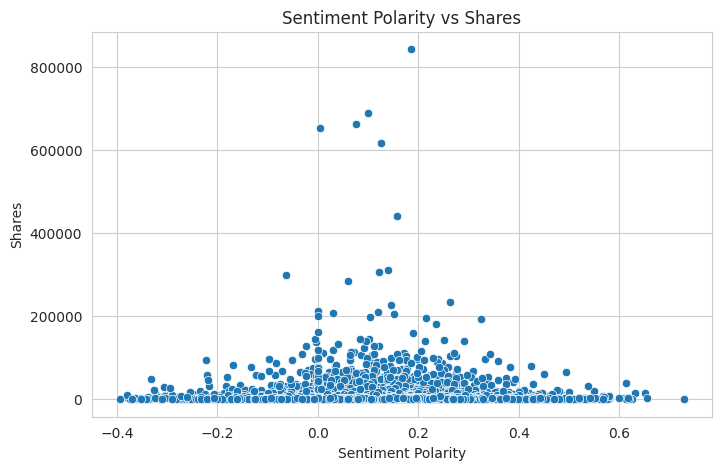

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['global_sentiment_polarity'],
    y=news_data['shares']
)

plt.title("Sentiment Polarity vs Shares")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Shares")

plt.show()

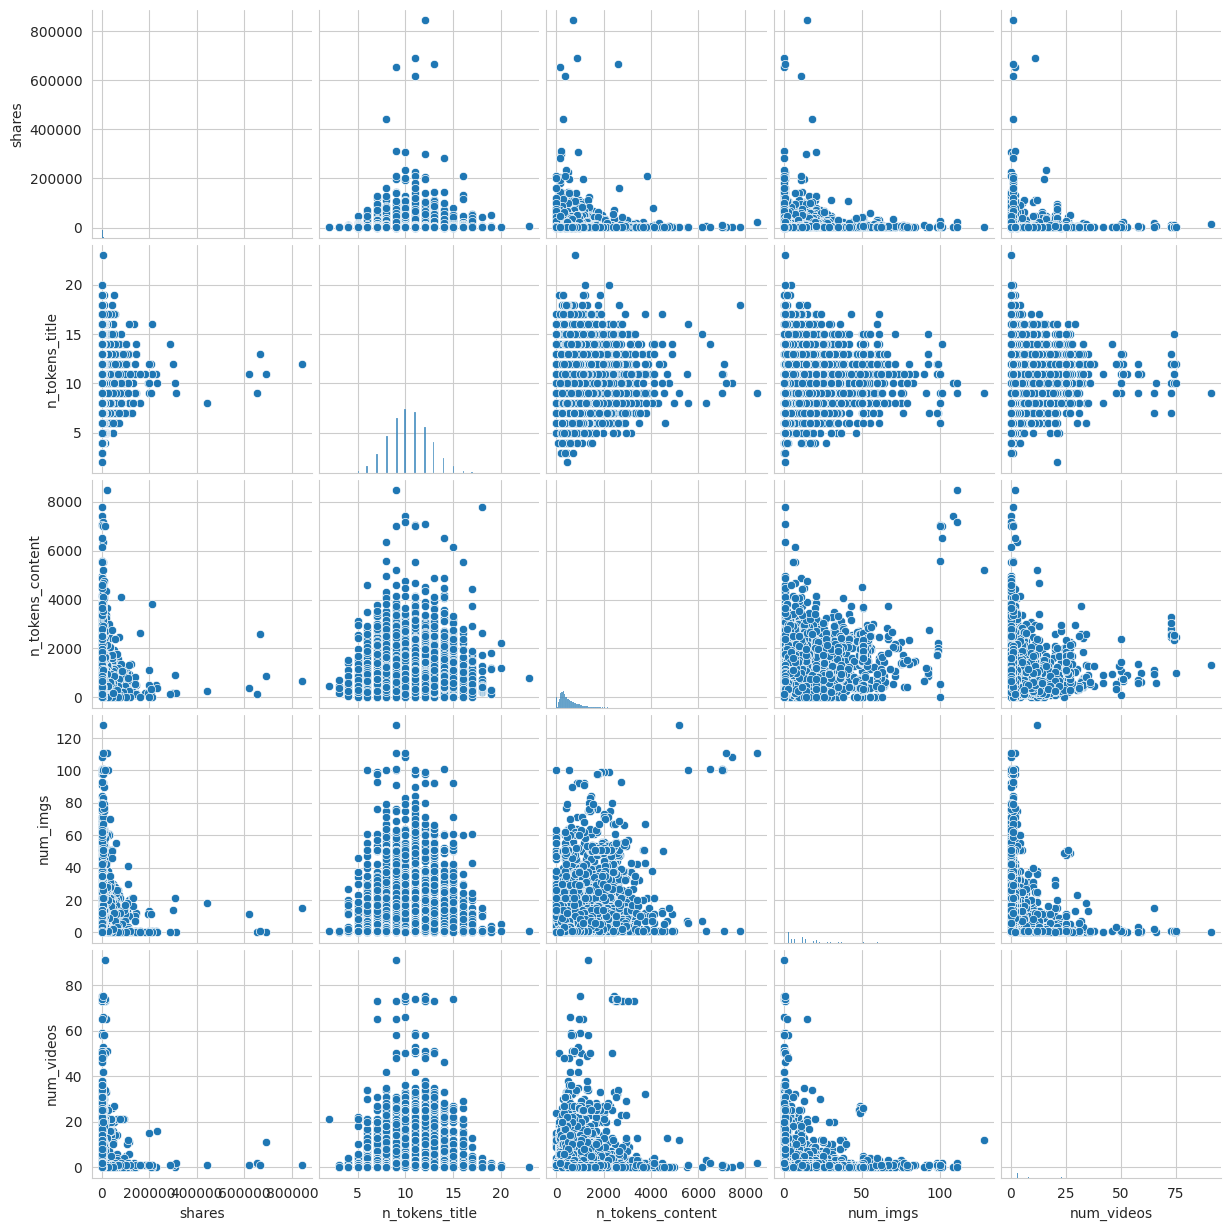

In [41]:
pairplot_features = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos'
]

sns.pairplot(news_data[pairplot_features])

plt.show()

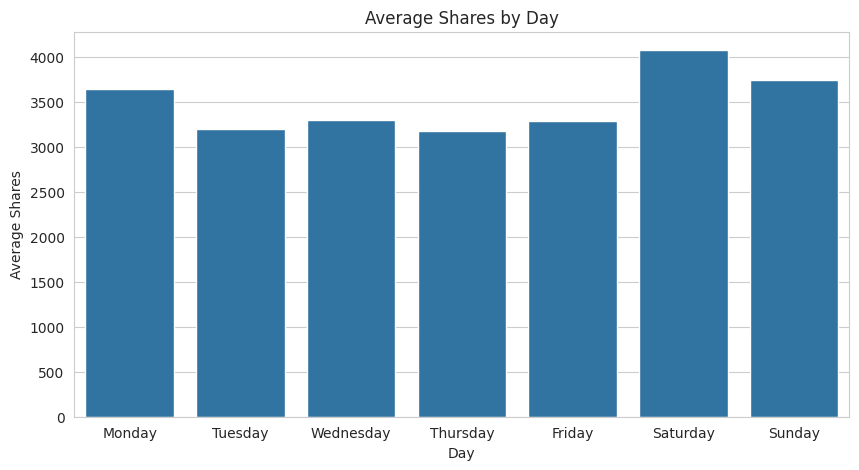

In [42]:
weekday_columns = [
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday'
]



weekday_shares = []

for day in weekday_columns:

    average_shares = news_data[news_data[day] == 1]['shares'].mean()

    weekday_shares.append(average_shares)



days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]



plt.figure(figsize=(10,5))

sns.barplot(
    x=days,
    y=weekday_shares
)

plt.title("Average Shares by Day")
plt.xlabel("Day")
plt.ylabel("Average Shares")

plt.show()



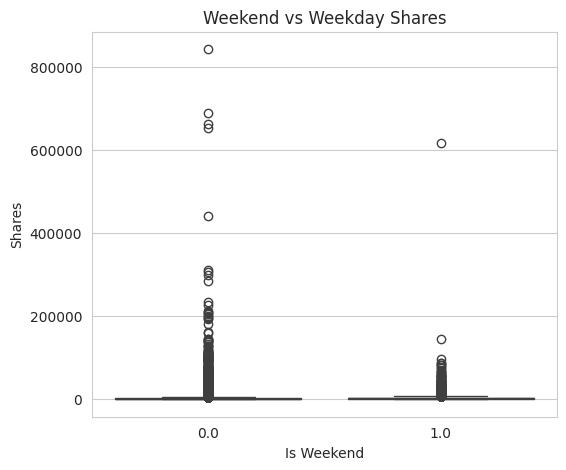

In [43]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x=news_data['is_weekend'],
    y=news_data['shares']
)

plt.title("Weekend vs Weekday Shares")
plt.xlabel("Is Weekend")
plt.ylabel("Shares")

plt.show()

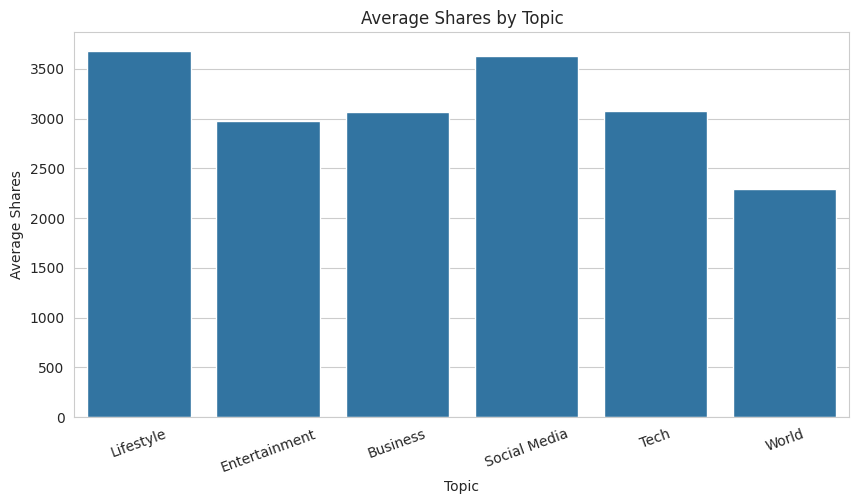

In [44]:
topic_columns = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]

topic_names = [
    'Lifestyle',
    'Entertainment',
    'Business',
    'Social Media',
    'Tech',
    'World'
]

topic_average_shares = []

for topic in topic_columns:

    avg_shares = news_data[news_data[topic] == 1]['shares'].mean()

    topic_average_shares.append(avg_shares)


plt.figure(figsize=(10,5))

sns.barplot(
    x=topic_names,
    y=topic_average_shares
)

plt.title("Average Shares by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Shares")

plt.xticks(rotation=20)

plt.show()

4541
1933
7703
2946
2169


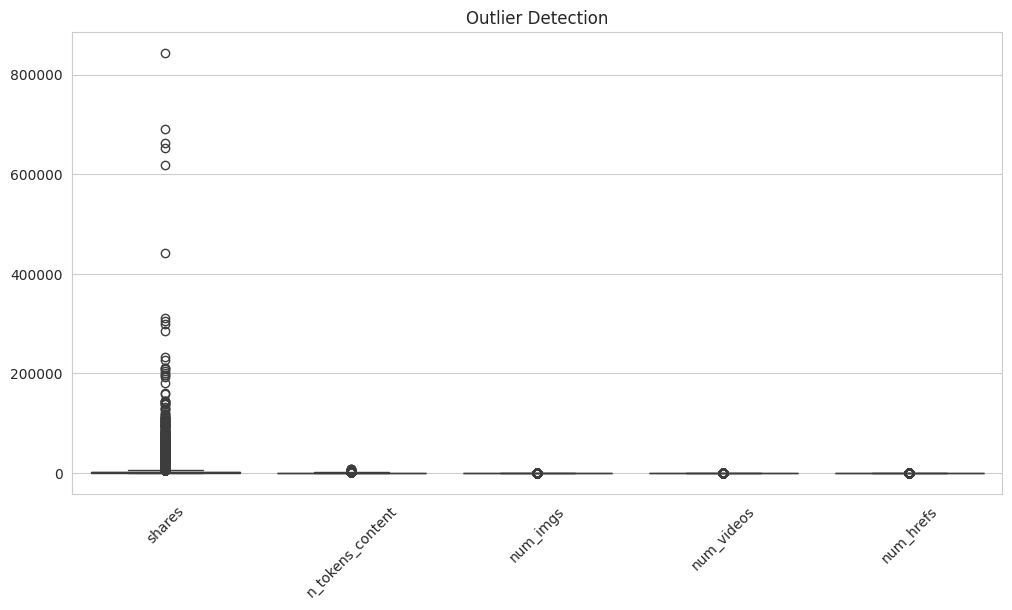

In [45]:

outlier_features = [
    'shares',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]



for column in outlier_features:

    Q1 = news_data[column].quantile(0.25)
    Q3 = news_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = news_data[
        (news_data[column] < lower_bound) |
        (news_data[column] > upper_bound)
    ]


    print(outliers.shape[0])



plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[outlier_features])

plt.title("Outlier Detection")

plt.xticks(rotation=45)

plt.show()



clipped_data = news_data.copy()

for column in outlier_features:

    Q1 = clipped_data[column].quantile(0.25)
    Q3 = clipped_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clipped_data[column] = clipped_data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )




In [46]:

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)



scaling_data = news_data.drop(columns=['url'])



standard_scaler = StandardScaler()

standard_scaled_data = standard_scaler.fit_transform(scaling_data)

standard_scaled_data = pd.DataFrame(
    standard_scaled_data,
    columns=scaling_data.columns
)




In [47]:


minmax_scaler = MinMaxScaler()

minmax_scaled_data = minmax_scaler.fit_transform(scaling_data)

minmax_scaled_data = pd.DataFrame(
    minmax_scaled_data,
    columns=scaling_data.columns
)



In [48]:

robust_scaler = RobustScaler()

robust_scaled_data = robust_scaler.fit_transform(scaling_data)

robust_scaled_data = pd.DataFrame(
    robust_scaled_data,
    columns=scaling_data.columns
)

